In [25]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [23]:
def get_simulation_data(filepath):
    
    with open(filepath, 'r') as file:
        lines = file.readlines()
        
    init_line = [line for line in lines if line.startswith("# Initial Conditions")][0]
    
    q_match = re.search(r'q=([0-9.]+)', init_line)
    chi1_match = re.search(r'χ1=([0-9.]+)', init_line)
    chi2_match = re.search(r'χ2=([0-9.]+)', init_line)
    
    q = float(q_match.group(1)) if q_match else 1.0
    chi1_mag = float(chi1_match.group(1)) if chi1_match else 0.0
    chi2_mag = float(chi2_match.group(1)) if chi2_match else 0.0
    
    print(f"Extracted initial conditions: q={q}, chi1={chi1_mag}, chi2={chi2_mag}")

    df = pd.read_csv(filepath, comment='#')
    
    theta1 = df['theta1_rad'].values
    theta2 = df['theta2_rad'].values
    time_steps = df['time_M'].values
    orbital_separation = df['separation_M'].values
    
    chi1_parallel = chi1_mag * np.cos(theta1)
    chi2_parallel = chi2_mag * np.cos(theta2)
    
    return {
        'time': time_steps,
        'q': q,
        'chi1_parallel': chi1_parallel,
        'chi2_parallel': chi2_parallel,
        'a' : orbital_separation
    }

In [18]:
def healy_final_mass(q, chi1_parallel, chi2_parallel, M_tot=1.0):
    
    eta = q / (1.0 + q)**2
    S_par = chi1_parallel + chi2_parallel
    Delta_par = chi1_parallel - chi2_parallel
    
    # Non-spinning term
    e0 = 0.04827
    e1 = 0.01707
    
    # Spin-Orbit term 
    f0 = 0.01191
    f1 = 0.02762
    g0 = -0.00755
    g1 = 0.01804
    
    # Spin-Spin term 
    h0 = 0.00485
    h1 = 0.02325
    i0 = 0.00346
    i1 = 0.01160
    j0 = -0.00161
    j1 = -0.01323

    E0_term = eta * (e0 + e1 * eta)
    
    ESO_term = (eta * S_par * (f0 + f1 * eta)) + \
               (eta * Delta_par * (g0 + g1 * eta))
               
    ESS_term = (eta * (S_par**2) * (h0 + h1 * eta)) + \
               (eta * (Delta_par**2) * (i0 + i1 * eta)) + \
               (eta * S_par * Delta_par * (j0 + j1 * eta))
               
    E_rad = E0_term + ESO_term + ESS_term
    
    Mf_array = M_tot * (1.0 - E_rad)
    
    return Mf_array

In [24]:
filepath = "/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q:0.40_χ1:0.50_χ2:0.50_θ1:45_θ2:45_ΔΦ:90.csv"

data = get_simulation_data(filepath) 

time_array = data['time']
mass_ratio = data['q']
chi1_par = data['chi1_parallel']
chi2_par = data['chi2_parallel']
separation_array = data['a']

Mf_array = healy_final_mass(mass_ratio, chi1_par, chi2_par, M_tot=1.0)

Extracted initial conditions: q=0.4, chi1=0.5, chi2=0.5


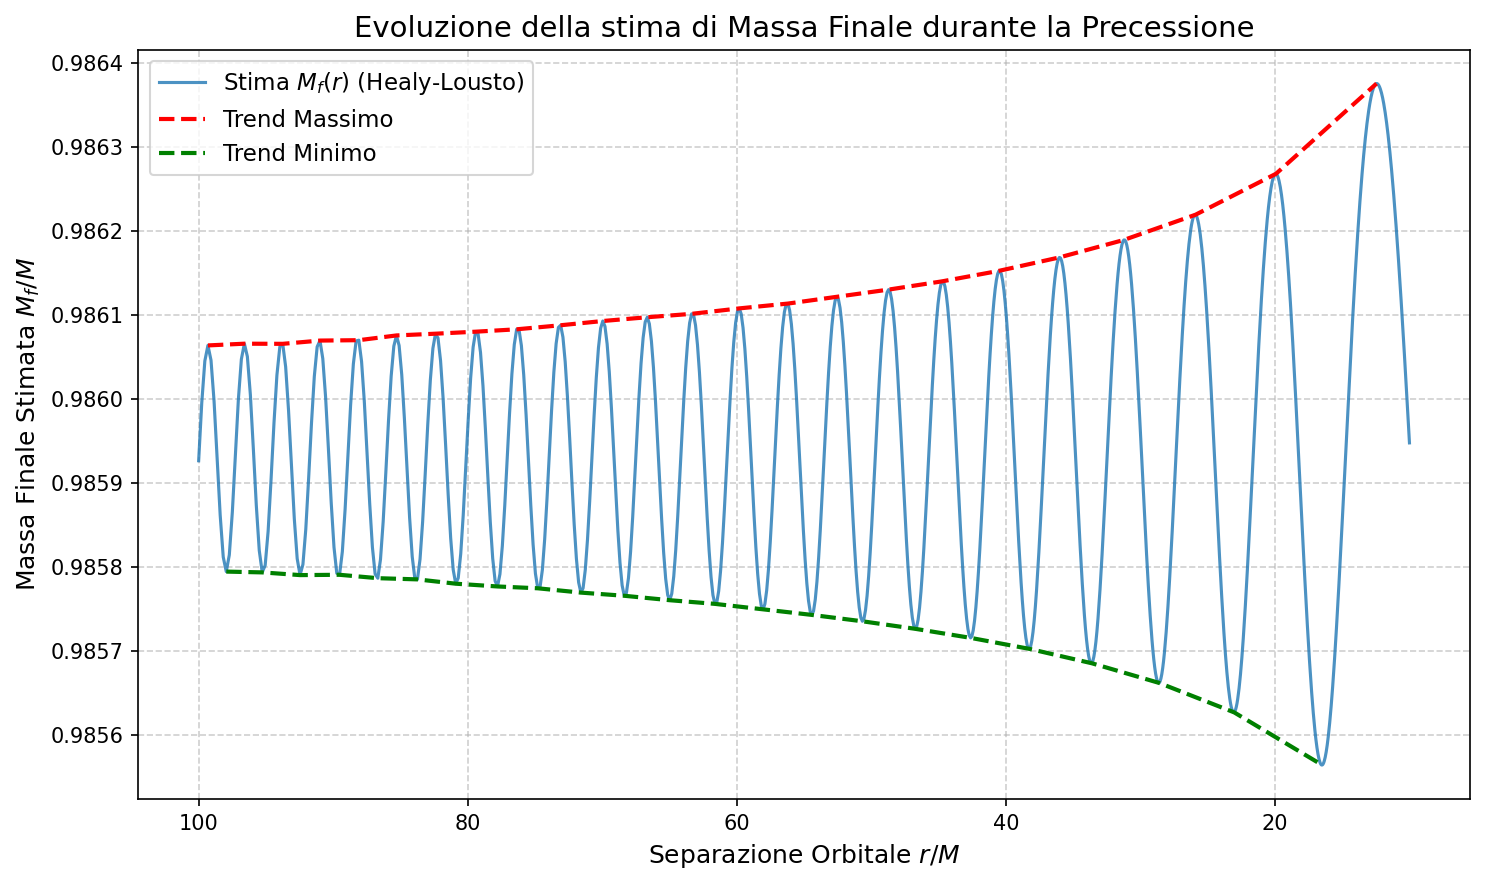

In [26]:
plt.figure(figsize=(10, 6), dpi=150)

# 1. Traccia il segnale usando separation_array al posto di time_array
plt.plot(separation_array, Mf_array, color='#1f77b4', linewidth=1.5, alpha=0.8,
         label=r'Stima $M_f(r)$ (Healy-Lousto)')

# 2. Sostituiamo la Media Mobile con gli Inviluppi (Trend Secolare corretto)
picchi_alti, _ = find_peaks(Mf_array, distance=5)
picchi_bassi, _ = find_peaks(-Mf_array, distance=5)

if len(picchi_alti) > 0 and len(picchi_bassi) > 0:
    plt.plot(separation_array[picchi_alti], Mf_array[picchi_alti], color='red', 
             linestyle='--', linewidth=2, label='Trend Massimo')
    plt.plot(separation_array[picchi_bassi], Mf_array[picchi_bassi], color='green', 
             linestyle='--', linewidth=2, label='Trend Minimo')

# 3. Formattazione
plt.title('Evoluzione della stima di Massa Finale durante la Precessione', fontsize=14)
plt.xlabel(r'Separazione Orbitale $r/M$', fontsize=12) # Etichetta aggiornata
plt.ylabel(r'Massa Finale Stimata $M_f / M$', fontsize=12)

# 4. INVERSIONE ASSE X (Fondamentale!)
# La separazione parte da valori alti (es. 100M) e scende a 0 al merger.
# Invertendo l'asse, il tempo "scorre" visivamente da sinistra verso destra.
plt.gca().invert_xaxis()

plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()